In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

#ref: https://matplotlib.org/stable/tutorials/pyplot.html

In [2]:
results_file = f"{os.getcwd()}/data/imax_results.json"

results = {}
with open(results_file, "r", encoding="utf-8") as file:
    results = json.load(file)

In [3]:
accuracy = [] # accuracy (score)
train_time = [] # time (training time)
subsets = [] # % of instances

for node_name, data in results.items():
    for subset, node_results in data.items():
        accuracy.append(node_results['score'])
        train_time.append(node_results['duration'])
        subsets.append(int(subset))
        print(f"{node_name}: subset={subset}%, score={node_results['score']}, training_time={node_results['duration']} seconds")

# dataframe with 3 columns (subset, traning time, score)
df = pd.DataFrame(
    {
        'subset': subsets,
        'train_time': train_time,
        'accuracy': accuracy
    }
)

# sort the table by subset in increasing order
df = df.sort_values('subset')

WORKER3: subset=5%, score=0.9251968503937008, training_time=0.092399 seconds
WORKER3: subset=30%, score=0.9278215223097113, training_time=0.212384 seconds
WORKER3: subset=55%, score=0.9396325459317585, training_time=0.355325 seconds
WORKER3: subset=80%, score=0.9440069991251093, training_time=0.485565 seconds
WORKER0: subset=10%, score=0.926071741032371, training_time=0.115683 seconds
WORKER0: subset=35%, score=0.9326334208223972, training_time=0.236619 seconds
WORKER0: subset=60%, score=0.9422572178477691, training_time=0.38179 seconds
WORKER0: subset=85%, score=0.9448818897637795, training_time=0.511601 seconds
WORKER2: subset=15%, score=0.9247594050743657, training_time=0.142671 seconds
WORKER2: subset=40%, score=0.9352580927384077, training_time=0.26476 seconds
WORKER2: subset=65%, score=0.9413823272090989, training_time=0.421868 seconds
WORKER2: subset=90%, score=0.9461942257217848, training_time=0.548755 seconds
WORKER4: subset=20%, score=0.926071741032371, training_time=0.162589

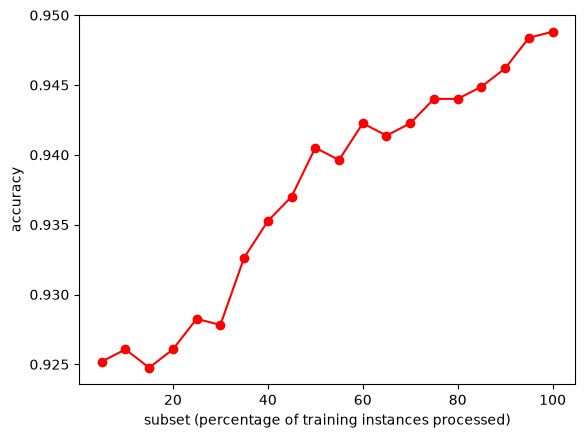

In [4]:
plt.plot(df['subset'], df['accuracy'], 'ro-')
plt.ylabel("accuracy")
plt.xlabel("subset (percentage of training instances processed)")
plt.show()

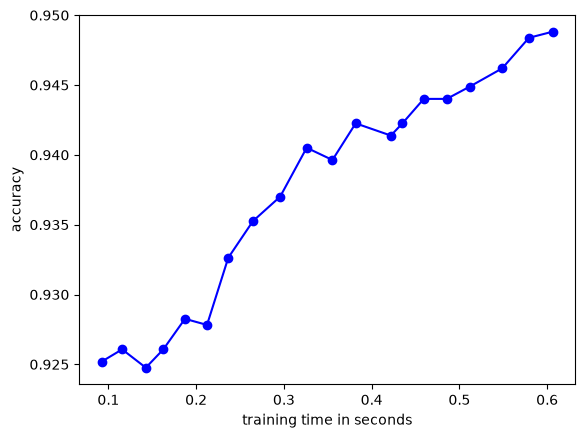

In [5]:
plt.plot(df['train_time'], df['accuracy'], 'bo-')
plt.ylabel("accuracy")
plt.xlabel("training time in seconds")
plt.show()

In [6]:
from kneed import KneeLocator

# ref: https://pypi.org/project/kneed/

In [7]:
# find knee (elbow) point between training time and score
kl = KneeLocator(df['train_time'], df['accuracy'], curve="concave", direction="increasing")

# these are the "best" training time and score
optimal_train_time = kl.knee
optimal_accuracy = kl.knee_y

optimal_subset = -1

# find the subset that has these train time and score
for node_name, data in results.items():
    for subset, node_results in data.items():
        if node_results['score'] == optimal_accuracy and node_results['duration'] == optimal_train_time:
            optimal_subset = subset
            break

In [8]:
print(f"optimal subset={optimal_subset}%:\n\ttrain_time={optimal_train_time}\n\taccuracy={optimal_accuracy}")

optimal subset=5%:
	train_time=0.092399
	accuracy=0.9251968503937008
